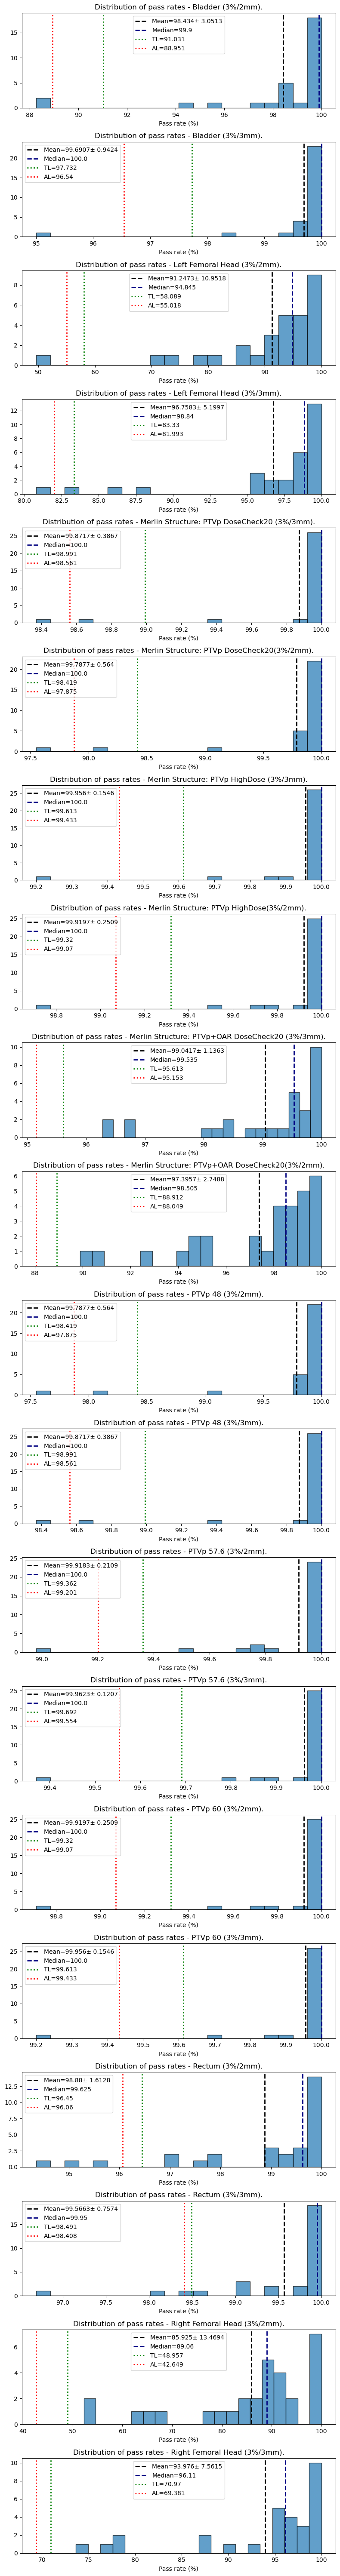

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# define functions
# description cleaning function
def extract_structure(desc):
    desc_clean = desc.replace("This is a Gamma 3D, mask on local. It includes the", "")
    desc_clean = desc_clean.replace("the Merlin Structure: ", "")
    return desc_clean.strip()

#NOTE exact_structure will only return the name of the structure that is analysed.

# TL and AL calculation function
def calc_TL_AL(values, beta=6.0, T=100):
    x = np.array(values)
    # x.sort()  # sort the values in ascending order to maximise the TL.
    
    # establish variables
    n = len(x)
    x_bar = np.mean(x)
    variance = np.var(x, ddof=1)
    
    # Tolerance Limit (TL)
    #TL = x_bar - 2.660 * ((1 / (n - 1)) * np.sum(np.abs(x[1:] - x[:-1])))
    TL = x_bar - 2.660 * (1 / (n - 1)) * sum(abs(x[i] - x[i-1]) for i in range(1, n)) #NOTE this does not change the results. This makes more sense to me though so i will keep this
    # Action Limit (AL)
    AL = 100 - ((beta * (np.sqrt(variance + ((x_bar - T)**2)))) / 2)
    
    return TL, AL


#NOTE x will be the %GP rates for each organ to be considered

# loading the patient data 
filepath = r'C:\Users\slaar\Desktop\project\PatResults\PatResults' #NOTE filepath is the directory where each patient's PatResults-Eval_###.json file is stored.
results_path = r'C:\Users\slaar\Desktop\project\pinnacle_RS_comparison\\' #NOTE results_path is the directory where the results will be stored.

# store the patient data
patients_data = {}
for patient in os.listdir(filepath):
    #NOTE patient is the json file
    json_file_dir = os.path.join(filepath, patient)
    
    if os.path.isfile(json_file_dir): #NOTE TICK!!
        with open(json_file_dir, "r") as f: #NOTE reading the json file
            data = json.load(f)  #NOTE loading the json file into the variable data
        
        # extract only what is needed for analysis from the jsons
        reduced_data = [] 
        for i in data:
            reduced_data.append({
                "patientID": i.get("DicomIODInfo",{}).get("patientID",{}).get("patientID"),
                "Description": i.get("Description"),
                "pass_rate": i.get("AnalysisParams",{}).get("pass_rate")
                })
        patients_data[patient] = reduced_data

#NOTE for each patient there is only one json_file which contains the patientID and information of the structure and its pass rate 
#NOTE extract the json file information into data
#NOTE for each item in data, you extract the dictionary (with keys: patientID, Description and pass_rate) and append it to the list reduced_data
#NOTE reduced_data is the added to the patients_data dictionary with patient as the key and reduced_data as the values (with these patients, there are 20 strucutres)


# flatten into a dataframe for easy manipulation
df_list = []
for patient, entries in patients_data.items():
    #print(entries) #NOTE this will output the list of dictionaries for each patient 
    df = pd.DataFrame(entries)
    #NOTE df makes a table for each patient: first column is the index, 2nd is the patient ID name (the same for each table), 3rd is the decription of each structure (structure is different) and the 4th is the pass rate 
    df_list.append(df)

#NOTE df_list is a list of tables from df.


patients_df = pd.concat(df_list, ignore_index=True)
patients_df["structure"] = patients_df["Description"].apply(extract_structure)
# patients_df.to_csv(r'<*>', index=False) # * = put desired file directory here to save the patients_df as a csv file

#NOTE patients_df combines all the patients data into one table
#NOTE .apply(extract_structure) performs the function in the dataframe. the parameter of the function is patients_df['Description']
#NOTE so, first row (title row): patientID, Description, pass rate, structure


patients_df_2 = patients_df.pivot(index="patientID", columns="structure", values="pass_rate")
patients_df_2.reset_index(inplace=True)
patients_df_2.columns.name = None
#patients_df_2.to_csv(results_path+"30_unaltered_pn_pros_with_stats_patients_df_2.csv", index=False)

#NOTE patients_df_2's columns are patient1D, structure1, structure2, structure3, ... strucure20
#NOTE pivot table arrange the patients_df in this way


results = []
for col in patients_df_2.columns[1:]: #NOTE ignoring the file patientID column
    vals = patients_df_2[col].loc[[1,3,4,6,7,9,10,11,12,13,16,17,18,20,21,22,23,24,26,27,29]].values #NOTE iloc removed the first DATA row in patients_df_2, but this is part of the equation
    #print(vals)
    #print(len(vals))
    TL, AL = calc_TL_AL(vals, beta=6.0, T=100) #NOTE introduction of the variables x_bar and variance (from calc_TL_AL function)
    results.append({"structure": col,
                    "tolerance_limit": TL,
                    "action_limit": AL
                   })

#NOTE results is a 20-items-long list of dictionaries, with each dictionary having a specific structures AL and TL


#store results
results_df = pd.DataFrame(results, columns=["structure", "tolerance_limit", "action_limit"]).round(5)
#results_df.to_csv(results_path+"30_unaltered_pn_pros_with_stats_results_df.csv", index=False)

#NOTE results_df is the tabulated form of results


structures_df = patients_df_2.drop(columns=['patientID']) #NOTE removes the patientID column 
#structures_df.to_csv(results_path+"30_unaltered_pn_pros_with_stats_structures_df_local.csv", index=False) 
TL_dict = dict(zip(results_df['structure'], results_df['tolerance_limit']))
AL_dict = dict(zip(results_df['structure'], results_df['action_limit']))

#NOTE zip combines columns of the results_df together
#NOTE drop removed the column 'patientID'


#plotting the histogram data
fig, axes = plt.subplots(len(structures_df.columns),1,figsize=(8, 3*len(structures_df.columns)))

stats = [['structure', 'mean', 'std', 'median']]
#NOTE to prepare a table for the mean, std and median for each structure

for ax, col in zip(axes, structures_df.columns):
    data=structures_df[col]
    mean, sigma, median = np.mean(data), np.std(data, ddof=1), np.median(data)
    stats.append([col, np.round(mean, 4), np.round(sigma, 4), np.round(median, 4)])
    # histogram of the pass rates
    ax.hist(data, bins=20, alpha=0.7, edgecolor='black')
    # add mean measurement value line
    ax.axvline(mean, color='black', linestyle='dashed', linewidth=2, label=f'Mean={round(mean,4)}± {round(sigma, 4)}')
    ax.axvline(median, color='navy', linestyle='dashed', linewidth=2, label=f'Median={round(median,4)}')

    # add tl and al as vertical lines
    ax.axvline(TL_dict[col], color='green', linestyle='dotted', linewidth=2, label=f'TL={round(TL_dict[col],3)}')
    ax.axvline(AL_dict[col], color='red', linestyle='dotted', linewidth=2, label=f'AL={round(AL_dict[col],3)}')
    ax.set_title(f'Distribution of pass rates - {col}')
    ax.set_xlabel('Pass rate (%)')
    ax.legend()

stats_df = pd.DataFrame(stats[1:], columns=stats[0])
#stats_df.to_csv(results_path+"30_unaltered_pn_pros_with_stats.csv", index=False)

plt.tight_layout()
plt.savefig(results_path+'_unaltered_pn_pros_with_stats_histograms.png')

#plt.show()
